# Exercise 1: Model of a neuron and the learning process

## 1.1 Model of a neuron

Write a Python function, which calculates the output of a neuron. Assume a model of a neuron shown in Figure 1 with three inputs and a threshold. The threshold can be interpreted as an additional input with fixed input of $-1$ and weight $w_{10}$. The output of the function has to correspond to output of the neuron.

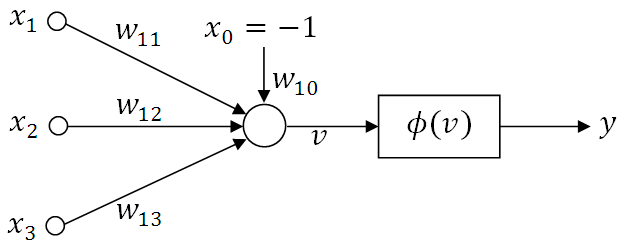

Figure 1. Model of a neuron

Use the scalar product of input vector $[x_0 x_1 x_2 x_3]$ and weights $[x_0 x_1 x_2 x_3]$ in order to calculate the neuron activation. The function has to have an additional input, which is used to select different nonlinear activation functions. The function should support the following nonlinear functions:

1. Step function
2. Piecewise linear function (ramp)
3. Sigmoid function defined as $\phi = \frac{1}{1+\exp (-av)}$, with $a=1$

**Tasks**

1. Write the code for calculating the aforementioned nonlinear functions and for the function which calculates the output of a neuron.

In [235]:
import numpy as np

def step_function(x):
    if x < 0:
      return 0
    else:
      return 1

def ramp_function(x):
    if x < -0.5:
      return 0
    elif x >= -0.5 and x <= 0.5:
      return x + 0.5
    else:
      return 1

def sigmoid_function(x, a=1):
    denominator = 1 + np.exp(-a*x)
    return 1/denominator

def neuron(x, w, activation):
    product = np.dot(x, w)
    output = activation(product)
    return output

**Tasks**

1. Pick a random weight vector $\mathbf{w}$. Write down the chosen weights and print the neuron response for following inputs (for each activation function):

$x_1 = [0.5, 1, 0.7]^T$

$x_2 = [0, 0.8, 0.2]^T$


In [236]:
w = np.array([0.3, 0.4, -0.25, 0.8])
x1 = np.array([-1, 0.5, 1, 0.7])
x2 = np.array([-1, 0, 0.8, 0.2])

print("Step function")
print(f"X1: {neuron(x1, w, step_function)}")
print(f"X2: {neuron(x2, w, step_function)}")

print("\nRamp function")
print(f"X1: {neuron(x1, w, ramp_function)}")
print(f"X2: {neuron(x2, w, ramp_function)}")

print("\nSigmoid function")
print(f"X1: {neuron(x1, w, sigmoid_function)}")
print(f"X2: {neuron(x2, w, sigmoid_function)}")

Step function
X1: 1
X2: 0

Ramp function
X1: 0.71
X2: 0.16000000000000003

Sigmoid function
X1: 0.5523079095743253
X2: 0.4158094770645927


## 1.2 Three neuron network

Write a function for a three neuron network (Figure 2) using the function developed in section 1.1.. Assume that neurons use the sigmoid transfer function, where $a=1$ and assume the weights are given as follows:

$w_1=[1, 0.5, 1, -0.4]$

$w_2=[0.5, 0.6, -1.5, -0.7]$

$w_3=[-0.5, -1.5, 0.6]$

*Remark*: The first element of the weight vector is the threshold of a neuron and is shown as $w_{i0}$ in Figure 2.

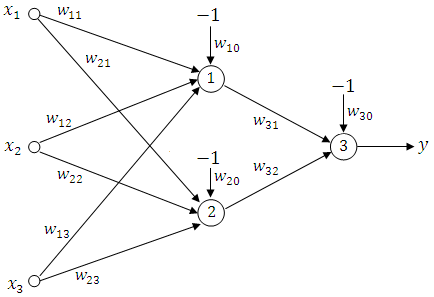

Figure 2. Three neuron network



**Tasks**

1. Write the code for calculating the output of the network shown in Fig. 2.

In [237]:
def three_neuron_network(x):
    hidden_layer_1 = neuron(x, w1, sigmoid_function)
    hidden_layer_2 = neuron(x, w2, sigmoid_function)
    hidden_layer_x = np.array([-1, hidden_layer_1, hidden_layer_2])
    output_layer = neuron(hidden_layer_x, w3, sigmoid_function)
    return output_layer


**Tasks**

1. Print the output of the network for input given as $x=[0.3, 0.7, 0.9]^T$.
2. Does the output of the network depend on neuron weights?

In [238]:
x = np.array([-1, 0.3, 0.7, 0.9])
w1 = np.array([1, 0.5, 1, -0.4])
w2 = np.array([0.5, 0.6, -1.5, -0.7])
w3 = np.array([-0.5, -1.5, 0.6])
print(f"Three neuron network: {three_neuron_network(x)}")

w3 = np.array([0.5, 1.5, -0.6])
print(f"Three neuron network with -w3: {three_neuron_network(x)}")

Three neuron network: 0.5021828523608841
Three neuron network with -w3: 0.4978171476391159


Output of the nework depends on the neuron weight as they are used for dot product in the calculation. That can be seen in the previous example by using negative w3 instead of original one. The differene in output is in region of 0.005

## 1.3 Delta rule

The goal of this experiment is to better understand the learning process. In this experiment we will implement a logical AND function using one neuron with two inputs and a threshold (see Figure 3). We will use the sigmoid nonlinear activation function with $a=1$.

For the learning phase, we have to define the following input output pairs $x_i$, $y_i$ for the logical AND function: for inputs $x_1=[-1, 0, 0]^T$, $x_2=[-1, 0, 1]^T$, and $x_3=[-1, 1, 0]^T$ the output $y$ should be equal to $0$; for input vector $x_4=[-1, 1, 1]^T$ the output value $y$ should be equal to $1$. The first component of all input vectors has value $-1$ and defines the neuron threshold visible as $w_{10}$ in Fig. 3. At the beginning we set the neuron weights to random values. We use the delta rule in order to update the weights:

$$\Delta w_{kj}=\eta e_{k}(n)x_{j}(n)$$

where

$$e_{k}(n)=d_{k}(n)-y_{k}(n)$$

where $d_{k}(n)$ is the expected neuron output and $y_{k}(n)$ is the obtained neuron output. This iterative procedure is repeated until the error is sufficiently small.

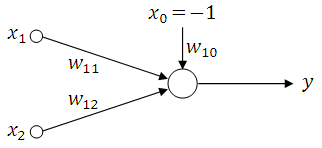

Figure 3. One neuron network

**Tasks**

1. Write the code which iteratively calculates the output of the network and uses the delta rule to update the weights until the error is sufficiently small. Experiment with different starting weights and different learning rates. (In case of instabilities, perform the experiment using a small learning rate, for example $\eta =0.05$). Show the error function ($y$-axis) and number of iterations ($x$-axis) for different learning rates.

    - What is the best learning rate? How does the learning rate affect the neural network?
    - How did you define the sufficiently small error used to terminate the algorithm?
    - After how many iterations does the algorithm terminate?


**Answers**

*1.* The best learning rate can be detected by observing learning curves. Learning rate of value = 0.5 has the best performing curve because the error decreases with every epoch and curve looks the usual learning curve. It is not the fastest but it fast enough and does not have any instabilities as higher learning rates. By increasing learning rates neural network is "faster", in other words the error reaches sufficiently small values faster.

*2.* To terminate the algorithm, average squared epoch error from all inputs needs to less than 0.01.

*3.* The number of iteration to terminate for corresponded learning rates can be seen in figure below. For example, learning rate of 0.5 terminates in 85 epochs.

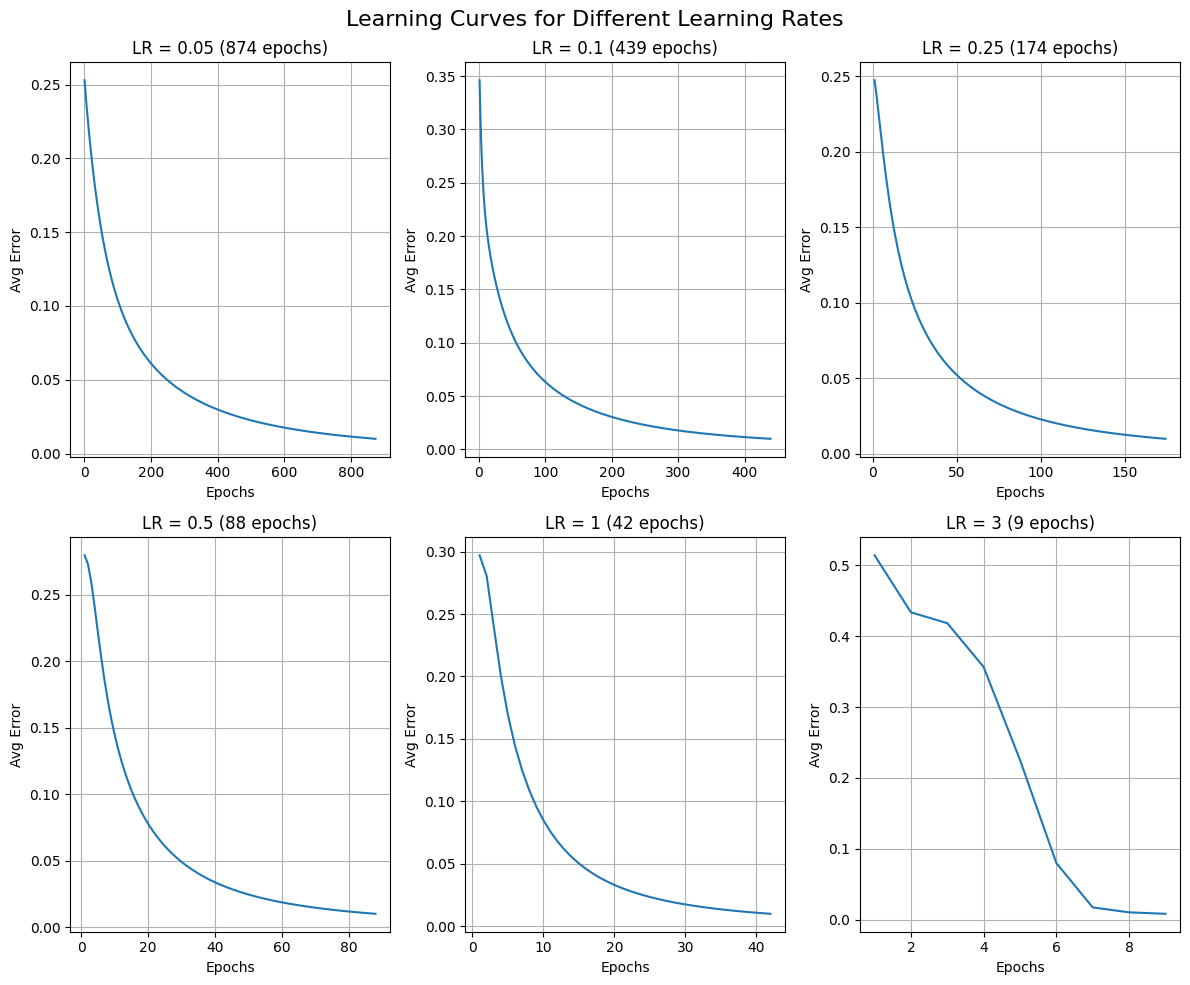

In [239]:
import matplotlib.pyplot as plt

def train_network(lr):
  x1 = [-1, 0, 0]
  x2 = [-1, 0, 1]
  x3 = [-1, 1, 0]
  x4 = [-1, 1, 1]
  w_rand = np.random.randn(3)
  x = np.array([x1, x2, x3, x4])
  y = np.array([0, 0, 0, 1])
  epochs = 0
  epoch_errors = []
  large_error = True
  while large_error:
    errors = []
    large_error = False
    epochs += 1
    for i in range(len(x)):
      pred = neuron(x[i], w_rand, sigmoid_function)
      error = y[i] - pred
      errors.append(error ** 2)
      delta = lr * error * x[i]
      w_rand = w_rand + delta

    epoch_errors.append(np.mean(errors))
    if np.mean(errors) > 0.01:
        large_error = True

  return epochs, epoch_errors

lrs = [0.05, 0.1, 0.25, 0.5, 1, 3]

fig, axes = plt.subplots(2, 3, figsize=(12, 10))
fig.suptitle('Learning Curves for Different Learning Rates', fontsize=16)

# Flatten axes for easier iteration
axes = axes.flatten()

for idx, lr in enumerate(lrs):
    epochs, errors = train_network(lr)
    axes[idx].plot(range(1, epochs + 1), errors)
    axes[idx].set_xlabel('Epochs')
    axes[idx].set_ylabel('Avg Error')
    axes[idx].set_title(f'LR = {lr} ({epochs} epochs)')
    axes[idx].grid(True)

plt.tight_layout()
plt.show()

# Exercise 2: Associative memory

## 2.1 Forming the correlation matrix directly

In this part of the exercise we will use the direct approach in forming the correlation matrix. Memory based on the correlation matrix should memorize input-output association pairs represented as vectors. For each input vector (key) the memory has to memorize the output pattern i.e. vector in an ASCII code formulation. In this example we will use 4-dimensional input and output vectors. Words (output vectos) that have to be memorized are: '*vrat*' , '*kraj*' , '*cres*' , '*otac*'. Vectors $b_i$, which represent those words should be formed as follows:

In [240]:
real=lambda x: np.array([[ord(character) for character in x]]).T

b1=real("vrat")
b2=real("kraj")
b3=real("cres")
b4=real("otac")

### 2.1.1 Orthogonal input vectors

This experiment demonstrates how to create an associative memory. Ortonormalized set of vectors defined as below

In [241]:
a1 = np.array([[1, 0, 0, 0]]).T
a2 = np.array([[0, 1, 0, 0]]).T
a3 = np.array([[0, 0, 1, 0]]).T
a4 = np.array([[0, 0, 0, 1]]).T

is used as input vector set (set of keys). We form the memory correlation matrix $\mathbf{M}$ using input output pairs as follows:

In [242]:
M = b1 * a1.T + b2 * a2.T + b3 * a3.T + b4 * a4.T
print(M)

[[118 107  99 111]
 [114 114 114 116]
 [ 97  97 101  97]
 [116 106 115  99]]


In order to verify whether the memory is functioning properly, we have to calculate outputs for each input vector. For example, the output for the key $a_1$ can be obtained as follows:

In [243]:
char=lambda x:"".join(map(chr, map(int, list(x))))

word=char(M@a1)
print(word)

vrat


/tmp/ipython-input-3483991913.py:1: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  char=lambda x:"".join(map(chr, map(int, list(x))))


**Tasks**

For each key, print the key and the corresponding output.
1. Were all input-output pairs memorized correctly?
2. How many input-output pairs would be memorized if vectors $a_i$ were not normalized?

**Answers**

**1.** All input-output pairs were memorized correctly as shown below.

**2.** Still 4 input-output pairs would me memorized if vectors a_i were not normalized but the result would be scaled outputs and it would not match the expected pattern.

In [244]:
orto_vec = [a1, a2, a3, a4]
for vec in orto_vec:
  word = char(M@vec)
  print(f"Word: {word}")

Word: vrat
Word: kraj
Word: cres
Word: otac


/tmp/ipython-input-3483991913.py:1: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  char=lambda x:"".join(map(chr, map(int, list(x))))


### 2.1.2 Correlation matrix properties

The goal of this experiment is to demonstrate the capacity of obtained memory. In this part of the exercise we will try to memorize one more (fifth) word ('*mrak*'). In 4-dimensional vector space the maximum number of linearly independent vectors is four. Because of this fact, we pick an arbitrary unit vector as the fifth key, for example:

In [245]:
a5 = (a1 + a3) / np.sqrt(2)


Form vectors $b_5$ ('*mrak*') and $a_5$ as explained and add them into the memory using the following expression:

In [246]:
b5 = real("mrak")
M_five = b1 * a1.T + b2 * a2.T + b3 * a3.T + b4 * a4.T + b5 * a5.T

**Tasks**

Once again, print each key and the corresponding output.
1. Was the new association properly memorized?
2. Did other associations stay correctly memorized?
    - If not - which were not memorized correctly and why?
    - If yes - which were memorized correctly and why?

**Answers**

*1.* New association was not properly memorized, retreiving it gave ĆēíĎ as result, not mrak.

*2.* Two other associations were also not memorized correctly and that are "vrat" and "cres" which are retrieved by a1 and a3. Vector a1 and a3 were used to form vector a5 which in 4-dim space cannot be indepedent if it is the fifth one. It is not linearly indepedent from a1 and a3 which causes interference. Because of that the keys "kraj" and "otac" which are retrived by a2 and a4 which were not used in configuring a5 and are linearly independent from it are correctly memorized.

In [247]:
orto_vec = [a1, a2, a3, a4, a5]
for vec in orto_vec:
  word = char(M_five@vec)
  print(f"Word: {word}")

Word: ÃÂ¥¿
Word: kraj
Word: °Â©¾
Word: otac
Word: ĆēíĎ


/tmp/ipython-input-3483991913.py:1: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  char=lambda x:"".join(map(chr, map(int, list(x))))


### 2.1.3 Word pairs as associations

In this experiment we will form the associative memory, which memorizes word pairs. The associations, which have to be memorized are: *ruka*-*vrat*, *kset*-*kraj*, *more*-*cres*, *mama*-*otac*. Generate input vectors (keys) as follows:

In [248]:
a1 = real("ruka")
a2 = real("kset")
a3 = real("more")
a4 = real("mama")
M = b1 * a1.T + b2 * a2.T + b3 * a3.T + b4 * a4.T
print(M)

[[47791 47867 46818 44624]
 [50264 50354 49352 47048]
 [43019 43124 42263 40271]
 [47892 48130 47019 44766]]


**Tasks**

1. What is the response for each input key?
2. Which associations were memorized correctly?
3. Which associations were not memorized correctly and why?
4. How can we fix this problem?

**Answers**

*1.* The response is not possible to get because of the error "char out of range". That is because the keys a1,a2,a3 and a4 are not orthonormalized and not unitary as well. Their value are shown below in the code output. Because of that by multiplying M with each key value that are calculated are out of range of ASCII table.

*2. and 3.* No association is memorized correctly because of the previously spoken error.

*4.* We can fix that problem by using keys that are orthonormalized.

In [249]:
orto_vec = [a1, a2, a3, a4]
print("Key that are not orthonormalized: ")
for vec in orto_vec:
  print(f"{vec.T}\n")
for vec in orto_vec:
  word = char(M@vec)
  print(f"Word: {word}")

Key that are not orthonormalized: 
[[114 117 107  97]]

[[107 115 101 116]]

[[109 111 114 101]]

[[109  97 109  97]]



/tmp/ipython-input-3483991913.py:1: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  char=lambda x:"".join(map(chr, map(int, list(x))))


ValueError: chr() arg not in range(0x110000)

### 2.1.4 Input vector orthogonalization

In this experiment we show an associative memory, which uses keys that are orthonormalized. We use the Gram-Schmidt orthogonalization method as follows. We first form the matrix $\mathbf{A}$ using vectors $a_i$:

In [271]:
A=np.hstack([a1, a2, a3, a4])

After this step we perform the orthonormalization step:

In [272]:
from scipy.linalg import orth
C=orth(A.T)

We extract individual orthonormal vectors $c_i$:

In [273]:
c1=np.array([C[0]]).T
c2=np.array([C[1]]).T
c3=np.array([C[2]]).T
c4=np.array([C[3]]).T

In the next step we form a new matrix $\mathbf{M}$ using vectors $c_i$ instead of vectors $a_i$ when creating the matrix $\mathbf{M}$.

In [274]:
M = b1 * c1.T + b2 * c2.T + b3 * c3.T + b4 * c4.T

**Tasks**

Verify the responses of matrix $\mathbf{M}$ with vectors $c_i$ as inputs.
1. What is the effect of vector orthonormalization?
2. How many pairs were correctly memorized?
3. What can we expect when normalizing the vectors?
4. What can we expect when only orthogonalizing the vectors?
5. What can we expect if vectors $c_i$ are linearly independent but not orthogonal?

**Answers**

*1.* Orthonormalization eliminates interference between patterns that are stored. Vectors are perpendiculat to each other - orthogonal and have unit length - normalized.

*2.* All pairs were correclty memorized because of the orthonormalization.

*3.* We can expect vector to have unit length but doing only that is not sufficient. There would still be interference between non-orthonogal ones. Retrivied outputs would be corrupted.

*4.* Interference would be eliminated but the output would be scaled as vector would not have unit length. Characters would have wrong ASCII values (the scaled ones).

*5.* We can expect partial interference and degree of it would depend on dot products between vectors. The closer the vector are to orthonogal the better the output would be and less interference.

In [275]:
orto_vec = [c1, c2, c3, c4]

print("Keys that are orthonormalized: ")
for vec in orto_vec:
  print(f"{vec.T}\n")

for vec in orto_vec:
  word = char(M@vec)
  print(f"Word: {word}")

Keys that are orthonormalized: 
[[-0.50594743  0.14847022  0.77925491  0.33872641]]

[[-0.50939047 -0.83525837 -0.19795538  0.06065043]]

[[-0.50546797  0.25257838 -0.01775974 -0.8248581 ]]

[[-0.47858195  0.46530012 -0.59435684  0.44854773]]

Word: vrat
Word: kraj
Word: cres
Word: otac


/tmp/ipython-input-3483991913.py:1: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  char=lambda x:"".join(map(chr, map(int, list(x))))


### 2.1.5 Finding the correlation matrix using matrix inversion

For previously used word pairs (*ruka*-*vrat*, *kset*-*kraj*, *more*-*cres*, *mama*-*otac*) find a $4\times 4$ correlation matrix $\mathbf{M}$ as $\mathbf{M} = \mathbf{B}\mathbf{A}^{-1}$, where matrix $\mathbf{B}$ is defined as:

In [276]:
B=np.hstack([b1, b2, b3, b4])
M=B@np.linalg.inv(A)

**Tasks**

1. Were all associations properly memorized? Remark: The result should be rounded to the nearest number before comparison.

**Answers**

*1.* All association were properly memorized.

In [277]:
orto_vec = [a1, a2, a3, a4]
for vec in orto_vec:
  word1 = char(np.round(M@vec))
  word2 = char(vec)
  print(f"First Word in pair: {word1}")
  print(f"Second Word in pair: {word2}\n")

First Word in pair: vrat
Second Word in pair: ruka

First Word in pair: kraj
Second Word in pair: kset

First Word in pair: cres
Second Word in pair: more

First Word in pair: otac
Second Word in pair: mama



/tmp/ipython-input-3483991913.py:1: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  char=lambda x:"".join(map(chr, map(int, list(x))))


### 2.1.6 Finding the correlation matrix using pseudo-inversion

A pseudo-inverse matrix can be used in order to find the correlation matrix when number of associations is larger than dimensionality of vectors representing the associations. In this case, the correlation matrix can be found as $\mathbf{M} = \mathbf{B}\mathbf{A}^{+}$, where $\mathbf{A}^{+}$ is a pseudo-inverse matrix defined as $\mathbf{A}^{+} = \mathbf{A}^{T}(\mathbf{A}\mathbf{A}^{T})^{-1}$.

Assume that the vectors $a_i$ and $b_i$ are defined previously (five associations in total). Find the pseudo-inverse matrix for this case.

In [278]:
a1 = np.array([[1, 0, 0, 0]]).T
a2 = np.array([[0, 1, 0, 0]]).T
a3 = np.array([[0, 0, 1, 0]]).T
a4 = np.array([[0, 0, 0, 1]]).T

a5 = (a1 + a3) / np.sqrt(2)

A=np.hstack([a1, a2, a3, a4, a5])
B=np.hstack([b1, b2, b3, b4, b5])
A_pseudo=A.T@np.linalg.inv(A@A.T)
M=B@A_pseudo

**Tasks**

1. Were all pairs memorized correctly?
2. If not, what is the error between expected and obtained values?

**Answers**

*1.* Two pairs were memorized correctly (kraj and otac).

*2.* For three pairs that were not memorized correctly the errors are display below in code output.

In [279]:
orto_vec = [a1, a2, a3, a4, a5]
real_words = [b1, b2, b3, b4, b5]

for vec, real_word in zip(orto_vec, real_words):
  word = char(M@vec)
  print(f"Word: {word}")
  print(f"Real word: {char(real_word)}")
  if word != char(real_word):
    print(f"Error by letter: {(M@vec - real_word).T}")
  print()

Word: faQ`
Real word: vrat
Error by letter: [[-15.71268043 -16.69491347 -15.20532111 -19.91978721]]

Word: kraj
Real word: kraj

Word: SaU_
Real word: cres
Error by letter: [[-15.71268043 -16.69491347 -15.20532111 -19.91978721]]

Word: otac
Real word: otac

Word: v
Real word: mrak
Error by letter: [[22.22108576 23.61017306 21.50357134 28.17083323]]



/tmp/ipython-input-3483991913.py:1: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  char=lambda x:"".join(map(chr, map(int, list(x))))


## 2.2 Finding the correlation matrix using supervised learning

This experiment shows us how to form the matrix $\mathbf{M}$ using supervised learning. In two following experiments we will use learning with error correction.

### 2.2.1 Learning with error correction

Form matrices $\mathbf{A}$ and $\mathbf{B}$ where each contains 4 vectors stacked in columns as explained in previous experiments. Check the contents of obtained matrices with following operations:

In [280]:
a1=real("ruka")
a2=real("kset")
a3=real("more")
a4=real("mama")

b1=real("vrat")
b2=real("kraj")
b3=real("cres")
b4=real("otac")

A=np.hstack([a1, a2, a3, a4])
B=np.hstack([b1, b2, b3, b4])

In order to start the learning procedure we have to initialize the matrix $\mathbf{M}$ (For example, random values uniformly generated in $[-0.5, 0.5]$ interval):

In [281]:
M=np.random.rand(4, 4)-0.5

For the learning part use the function *trainlms*, which is the implementation of the Widrow-Hoff LMS learning algorithm. The function can be used as follows:

In [282]:
def trainlms(A, B, M, ni, max_num_iter, min_err=0.02):
    d=B
    x=A
    w=M

    n=0
    err=[]
    while (n<max_num_iter):
        n+=1
        e=d-w@x
        w+=ni*np.dot(e, x.T)
        err.append(np.sum(np.sum(np.multiply(e, e))))
        if (err[-1]<min_err):
            break
    return w, err

where *max_num_iter* is the number of iterations and *ni* is the learning rate. Find the *max_num_iter* variable experimentally. For *ni* you can use:

In [283]:
ni=0.9999/np.linalg.eig(A @ A.T)[0].max()

The function trainlms performs the learning until SSE drops below $0.02$ or maximum number of iterations is performed. After the learning phase, look at the responses of the correlation matrix $\mathbf{M}$:

In [284]:
M, e=trainlms(A, B, M, ni, 100000)

If we type

In [285]:
np.round(M@A)==B

array([[ True,  True,  True,  True],
       [ True,  True,  True,  True],
       [ True,  True,  True,  True],
       [ True,  True,  True,  True]])

we will see, which characters were properly reconstructed: the positions with correct reconstructions will have value *True* and  other positions will have value *False*. By calling the *trainlms* multiple times we can extend the learning process and maybe increase the number of memorized characters but the proper way to extend the learning process is to increase the *max_num_iter* variable. We can draw a graph, which plots the error with number of iterations (in logaritmic scale) using the following commands:

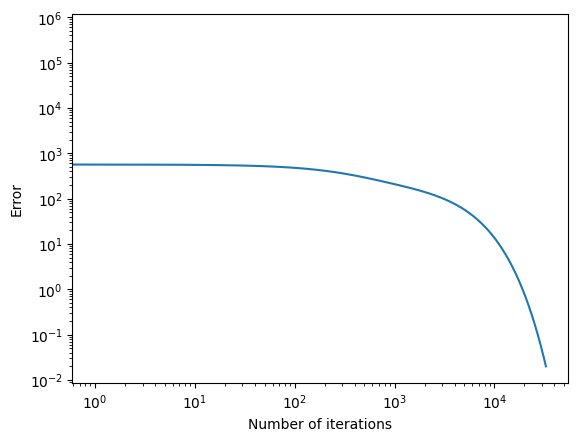

In [286]:
plt.plot(e)
plt.yscale("log")
plt.xscale("log")
plt.xlabel("Number of iterations")
plt.ylabel("Error")
plt.show()

**Tasks**

1. Plot a graph showing number of memorized characters tied to number of used iterations. (Caution: When building the graph, start the simulation with the same starting matrix.)

In [287]:
def trainlms_memorized_char(A, B, M, ni, max_num_iter, min_err=0.02):
    d=B
    x=A
    w=M

    n=0
    err=[]
    num_chars = []
    while (n<max_num_iter):
        n+=1
        e=d-w@x
        w+=ni*np.dot(e, x.T)
        err.append(np.sum(np.sum(np.multiply(e, e))))
        num_chars.append(np.sum(np.round(M@A)==B))
        if (err[-1]<min_err):
            break
    return w, err, num_chars

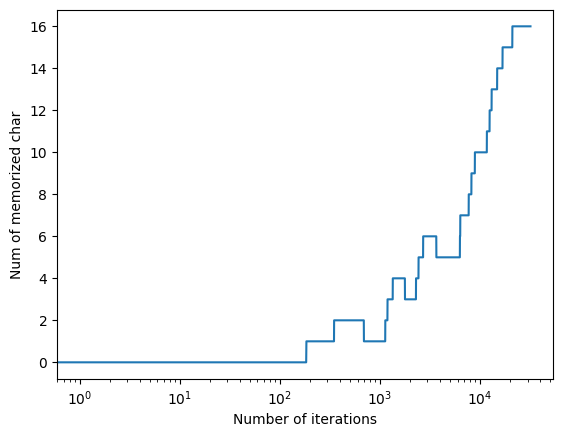

In [288]:
M = np.random.rand(4, 4)-0.5
M, e, num_chars=trainlms_memorized_char(A, B, M, ni, 100000)
plt.plot(num_chars)
plt.xscale("log")
plt.xlabel("Number of iterations")
plt.ylabel("Num of memorized char")
plt.show()

## 2.2.2 Effect of larger number of associations

This experiment demonstrates the capacity of the associative memory. What is the capacity of a $4\times 4$ correlation matrix based associative memory?

**Tasks**
1. For additional pair '*auto*'-'*mrak*' create vectors $a_5$ and $b_5$ as explained in the previous part of the exercise. Create new matrices A and B with dimensions $4$ (rows) $\times$ $5$ (columns) in the same way as previously explained. Initialize the matrix $\mathbf{M}$ with random starting values.

In [289]:
a5 = real("auto")
b5 = real("mrak")

A = np.hstack([a1, a2, a3, a4, a5])
B = np.hstack([b1, b2, b3, b4, b5])

M = np.random.rand(4, 4)-0.5

Use the *trainlms* function in the following way:

In [290]:
ni=0.9999/max(np.linalg.eig(np.dot(A, A.T))[0])
M, e=trainlms(A, B, M, ni, 100000)

print(f"It used {len(e)} iterations.")
print(f"{np.sum(np.round(np.dot(M, A))==B)} characters were memorized correctly")
print(f"SSE is {e[-1]}")
print(f"If the function is called from the beginning it will continue learning using new M but it will not improve that much.")
print(f"There are {np.sum(np.round(np.dot(M, A))==B)} memorized chars and error is {e[-1]} and there is not any difference because it reached optimum and the learning cannot continue from there.")


It used 100000 iterations.
2 characters were memorized correctly
SSE is 219.79844711685453
If the function is called from the beginning it will continue learning using new M but it will not improve that much.
There are 2 memorized chars and error is 219.79844711685453 and there is not any difference because it reached optimum and the learning cannot continue from there.


**Tasks**

1. How many iterations did you use?
2. How many characters were memorized correctly?
3. What is the SSE error?
4. What happens if we call the function from the beginning?
5. How many characters are correctly memorized now and how large is the mistake? Is there any difference and why?
6. Is it possible to train this network in order to memorize all five associations?
7. Why? (Explain the previous answer)

**Answers**

*1., 2., 3., 4. and 5. are answered in code output above*

*6. and 7.* It is not possible because M can only have 4 linear independent vector which means that that 5th and possibly any other associtation will always interfere and be linearly dependent of other vectors.